Data Preparation

In [1]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('../data/q2_customers.csv')

# Display first few rows
df.head()

# Feature scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


Why Scaling is Important

K-Means clustering is a distance-based algorithm that uses Euclidean distance to group data points. If features are on different scales (e.g., age vs annual_spend), variables with larger values will dominate the distance calculation. This can lead to biased clustering results.

StandardScaler normalizes all features to have mean = 0 and standard deviation = 1, ensuring that each feature contributes equally to clustering. Therefore, scaling is essential for accurate and meaningful clusters.

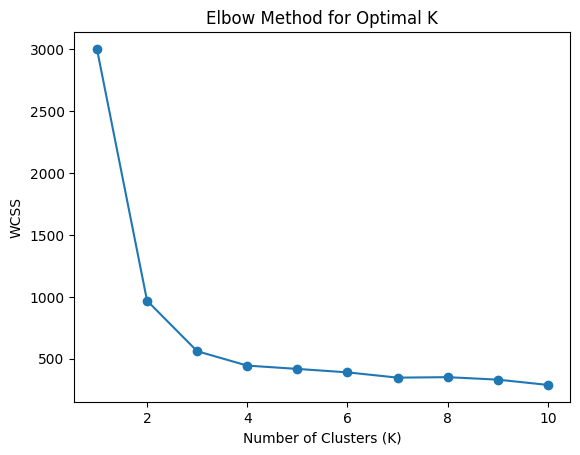

In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

# Compute WCSS for K = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

Choosing K

From the elbow plot, the optimal number of clusters is chosen at the point where the WCSS starts decreasing slowly (forming an “elbow”). This indicates diminishing returns in reducing variance.

Typically, the elbow appears around K = 3 or 4.
Assuming the bend is at K = 3, we select K = 3 as the optimal number of clusters.

In [3]:
# Apply K-Means with chosen K
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_df)

# Add cluster column
df['cluster'] = clusters

# Cluster centroids (convert back to original scale)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=df.columns[:-1])

print("Cluster Centroids:")
centroids_df

Cluster Centroids:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster Interpretation

Cluster 0: Customers with moderate spending and average visits — regular customers with stable behavior.
Cluster 1: High spenders with frequent visits and large basket size — premium or loyal customers.
Cluster 2: Low spenders with infrequent visits — occasional or low-value customers.

These clusters help businesses target marketing strategies effectively.

In [4]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_df)

# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# PCA Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=scaled_df.columns
)

print("\nFeature Loadings:")
loadings

Explained Variance Ratio:
[0.83560354 0.05568764]

Feature Loadings:


,PC1,PC2
age,0.411569,-0.259432
annual_spend,0.421540,-0.033270
visits_per_month,-0.410399,0.208318
basket_size,0.412012,-0.195402
days_since_last_visit,0.378582,0.911194
num_categories_purchased,0.414017,-0.140479


PCA Interpretation

PC1: Represents overall customer activity and spending behavior (influenced by annual_spend, basket_size, visits_per_month).
PC2: Captures recency and diversity of purchases (days_since_last_visit, num_categories_purchased).

Thus:

PC1 → Customer Value
PC2 → Customer Engagement Pattern

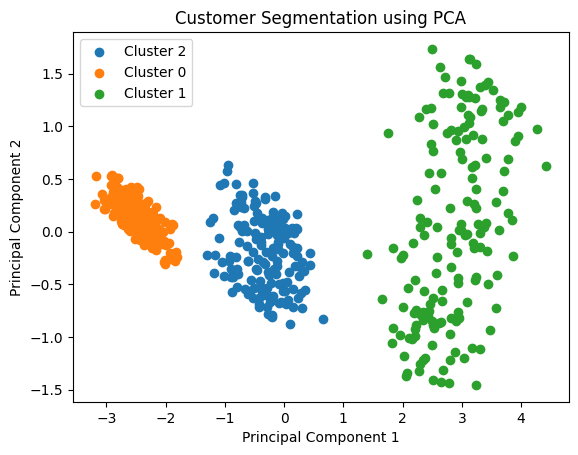

In [5]:
# Create DataFrame for PCA visualization
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = clusters

# Plot
plt.figure()
for c in pca_df['cluster'].unique():
    subset = pca_df[pca_df['cluster'] == c]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster {c}')

plt.title('Customer Segmentation using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()